In [1]:
import pandas as pd
from IPython.display import display, HTML

In [2]:
data = {
    'ตลาด': [
        'US (S&P 500)', 'US (S&P 500)',
        'UK (FTSE 100)', 'UK (FTSE 100)',
        'Thai (SET)', 'Thai (SET)',
        'Gold (Futures)', 'Gold (Futures)',
        'BTC (Bitcoin)', 'BTC (Bitcoin)',
    ],
    'Ticker': [
        '^GSPC', '^GSPC',
        '^FTSE', '^FTSE',
        '^SET.BK', '^SET.BK',
        'GC=F', 'GC=F',
        'BTC-USD', 'BTC-USD',
    ],
    'สภาวะ': [
        'Uptrend', 'Downtrend',
        'Uptrend', 'Downtrend',
        'Uptrend', 'Downtrend',
        'Uptrend', 'Downtrend',
        'Uptrend', 'Downtrend',
    ],
    'ช่วงวันที่': [
        '4 ม.ค. 2553 – 29 ธ.ค. 2560',
        '3 ม.ค. 2543 – 9 มี.ค. 2552',
        '2 มี.ค. 2552 – 1 พ.ค. 2558',
        '4 ม.ค. 2543 – 27 ก.พ. 2552',
        '5 ม.ค. 2552 – 30 ธ.ค. 2557',
        '11 ธ.ค. 2539 – 29 ธ.ค. 2543',
        '3 ม.ค. 2548 – 31 ส.ค. 2554',
        '1 ก.ย. 2554 – 1 ส.ค. 2561',
        '17 ก.ย. 2557 – 15 ธ.ค. 2560',
        '1 ม.ค. 2561 – 31 ธ.ค. 2562',
    ],
    'จำนวนวัน': [
        '2,013 วัน', '2,308 วัน',
        '1,557 วัน', '2,316 วัน',
        '1,463 วัน', '997 วัน',
        '1,675 วัน', '1,737 วัน',
        '1,186 วัน', '730 วัน',
    ],
}

df = pd.DataFrame(data)

In [3]:
def build_table(df):
    header_style = (
        'background-color:#000; color:#fff; font-weight:bold; '
        'text-align:center; padding:10px 14px; font-size:13px; '
        'border:1px solid #000;'
    )
    cell_base = 'padding:8px 14px; border:1px solid #000; font-size:13px; text-align:center;'
    cell_white = cell_base + ' background-color:#fff; color:#000;'
    cell_gray  = cell_base + ' background-color:#f2f2f2; color:#000;'

    columns = ['ตลาด', 'Ticker', 'สภาวะ', 'ช่วงวันที่', 'จำนวนวัน']

    html = ('<table style="border-collapse:collapse; width:100%; '
            'font-family:Sarabun,sans-serif; border:2px solid #000;">\n')

    # Caption
    html += ('<caption style="caption-side:top; font-size:14px; font-weight:bold; '
             'padding:10px 0 8px 0; color:#000; text-align:center;">'
             'ตารางที่ 2 ชุดข้อมูลฝึกสอนโมเดลแยกตามตลาดและสภาวะตลาด</caption>\n')

    # Header
    html += '<thead><tr>'
    for col in columns:
        html += f'<th style="{header_style}">{col}</th>'
    html += '</tr></thead>\n'

    # Body — สลับแถวขาว/เทาตามตลาด (2 แถวต่อตลาด)
    market_order = ['US (S&P 500)', 'UK (FTSE 100)', 'Thai (SET)', 'Gold (Futures)', 'BTC (Bitcoin)']
    html += '<tbody>'
    for idx, (_, row) in enumerate(df.iterrows()):
        market   = row['ตลาด']
        market_i = market_order.index(market)
        cell     = cell_gray if market_i % 2 == 0 else cell_white
        trend    = row['สภาวะ']

        # เส้นหนากั้นระหว่างตลาด
        bt = 'border-top:2px solid #000;' if idx % 2 == 0 else ''

        html += '<tr>'
        html += f'<td style="{cell} font-weight:bold; {bt}">{market}</td>'
        html += f'<td style="{cell} font-family:monospace; {bt}">{row["Ticker"]}</td>'

        # Uptrend = ตัวหนา, Downtrend = ตัวเอียง
        trend_html = f'<strong>{trend}</strong>' if trend == 'Uptrend' else f'<em>{trend}</em>'
        html += f'<td style="{cell} {bt}">{trend_html}</td>'

        html += f'<td style="{cell} {bt}">{row["ช่วงวันที่"]}</td>'
        html += f'<td style="{cell} font-weight:bold; {bt}">{row["จำนวนวัน"]}</td>'
        html += '</tr>\n'

    html += '</tbody></table>'
    return html

html_table = build_table(df)
display(HTML(html_table))

ตลาด,Ticker,สภาวะ,ช่วงวันที่,จำนวนวัน
US (S&P 500),^GSPC,Uptrend,4 ม.ค. 2553 – 29 ธ.ค. 2560,"2,013 วัน"
US (S&P 500),^GSPC,Downtrend,3 ม.ค. 2543 – 9 มี.ค. 2552,"2,308 วัน"
UK (FTSE 100),^FTSE,Uptrend,2 มี.ค. 2552 – 1 พ.ค. 2558,"1,557 วัน"
UK (FTSE 100),^FTSE,Downtrend,4 ม.ค. 2543 – 27 ก.พ. 2552,"2,316 วัน"
Thai (SET),^SET.BK,Uptrend,5 ม.ค. 2552 – 30 ธ.ค. 2557,"1,463 วัน"
Thai (SET),^SET.BK,Downtrend,11 ธ.ค. 2539 – 29 ธ.ค. 2543,997 วัน
Gold (Futures),GC=F,Uptrend,3 ม.ค. 2548 – 31 ส.ค. 2554,"1,675 วัน"
Gold (Futures),GC=F,Downtrend,1 ก.ย. 2554 – 1 ส.ค. 2561,"1,737 วัน"
BTC (Bitcoin),BTC-USD,Uptrend,17 ก.ย. 2557 – 15 ธ.ค. 2560,"1,186 วัน"
BTC (Bitcoin),BTC-USD,Downtrend,1 ม.ค. 2561 – 31 ธ.ค. 2562,730 วัน


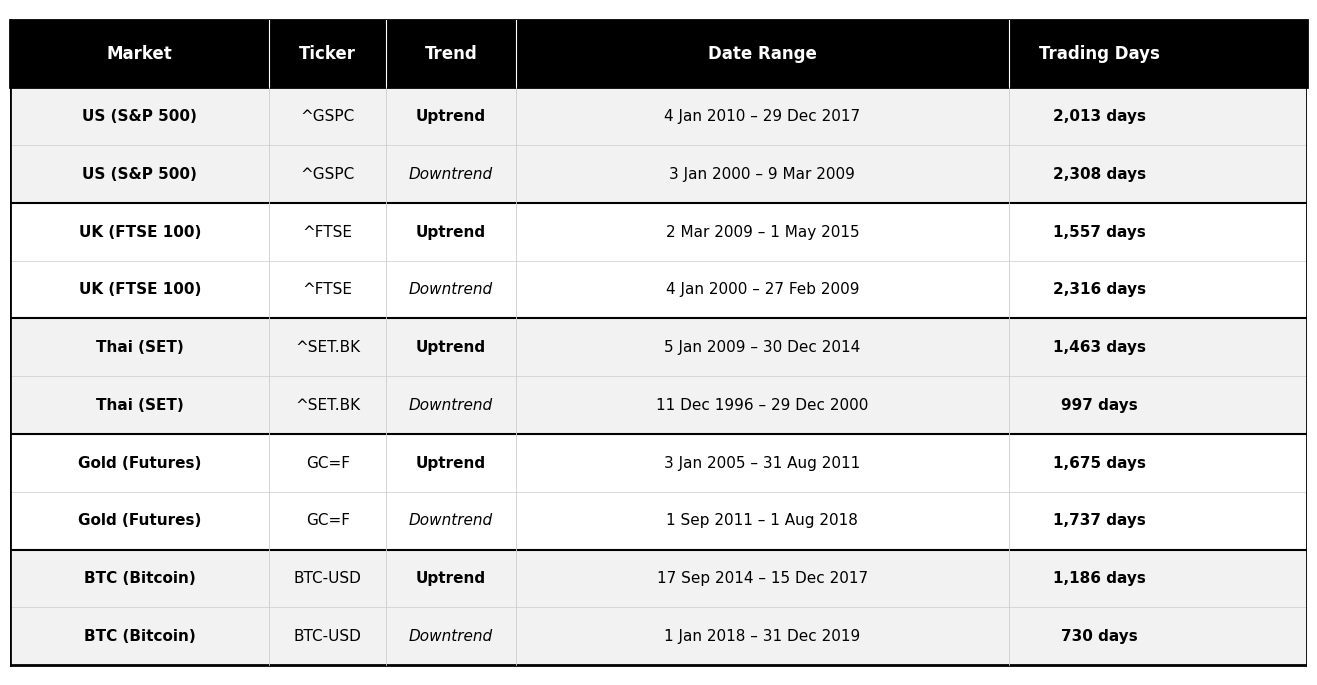

Saved → /Users/oattao/project/p-e/ipynb/image/table2_training_data.png


In [4]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ─── Data ────────────────────────────────────────────────────────
col_headers = ['Market', 'Ticker', 'Trend', 'Date Range', 'Trading Days']
col_widths  = [0.20, 0.09, 0.10, 0.38, 0.14]

rows = [
    ['US (S&P 500)',   '^GSPC',   'Uptrend',   '4 Jan 2010 – 29 Dec 2017',  '2,013 days'],
    ['US (S&P 500)',   '^GSPC',   'Downtrend', '3 Jan 2000 – 9 Mar 2009',   '2,308 days'],
    ['UK (FTSE 100)', '^FTSE',    'Uptrend',   '2 Mar 2009 – 1 May 2015',   '1,557 days'],
    ['UK (FTSE 100)', '^FTSE',    'Downtrend', '4 Jan 2000 – 27 Feb 2009',  '2,316 days'],
    ['Thai (SET)',    '^SET.BK',  'Uptrend',   '5 Jan 2009 – 30 Dec 2014',  '1,463 days'],
    ['Thai (SET)',    '^SET.BK',  'Downtrend', '11 Dec 1996 – 29 Dec 2000', '997 days'],
    ['Gold (Futures)','GC=F',    'Uptrend',   '3 Jan 2005 – 31 Aug 2011',  '1,675 days'],
    ['Gold (Futures)','GC=F',    'Downtrend', '1 Sep 2011 – 1 Aug 2018',   '1,737 days'],
    ['BTC (Bitcoin)', 'BTC-USD', 'Uptrend',   '17 Sep 2014 – 15 Dec 2017', '1,186 days'],
    ['BTC (Bitcoin)', 'BTC-USD', 'Downtrend', '1 Jan 2018 – 31 Dec 2019',  '730 days'],
]

# ─── Layout ──────────────────────────────────────────────────────
ROW_H    = 0.58
HEADER_H = 0.68
FIG_W    = 13.0
N_ROWS   = len(rows)
FIG_H    = HEADER_H + N_ROWS * ROW_H + 0.20

BLACK = '#000000'
WHITE = '#ffffff'
GRAY  = '#f2f2f2'
LGRAY = '#cccccc'

market_bg = {
    'US (S&P 500)':   GRAY,
    'UK (FTSE 100)':  WHITE,
    'Thai (SET)':     GRAY,
    'Gold (Futures)': WHITE,
    'BTC (Bitcoin)':  GRAY,
}

matplotlib.rcParams['font.family'] = ['DejaVu Sans']
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 1)
ax.set_ylim(0, FIG_H)
ax.axis('off')
fig.patch.set_facecolor(WHITE)

def cx(i):
    return sum(col_widths[:i])

# ── Header ────────────────────────────────────────────────────────
hdr_top = FIG_H - 0.10
hdr_bot = hdr_top - HEADER_H

ax.add_patch(mpatches.FancyBboxPatch(
    (0, hdr_bot), 1, HEADER_H,
    boxstyle='square,pad=0', facecolor=BLACK, edgecolor=BLACK,
    linewidth=2, clip_on=False))

for ci, (label, w) in enumerate(zip(col_headers, col_widths)):
    if ci > 0:
        ax.plot([cx(ci), cx(ci)], [hdr_bot, hdr_top],
                color=WHITE, linewidth=0.8, zorder=5)
    ax.text(cx(ci) + w / 2, (hdr_top + hdr_bot) / 2, label,
            ha='center', va='center',
            fontsize=12, fontweight='bold', color=WHITE)

ax.plot([0, 1], [hdr_bot, hdr_bot], color=BLACK, linewidth=2)

# ── Rows ──────────────────────────────────────────────────────────
prev_market = None
for ri, row_data in enumerate(rows):
    ry0 = hdr_bot - ri * ROW_H
    ry1 = ry0 - ROW_H
    market = row_data[0]

    ax.add_patch(mpatches.FancyBboxPatch(
        (0, ry1), 1, ROW_H,
        boxstyle='square,pad=0', facecolor=market_bg[market],
        edgecolor='none', clip_on=False))

    is_new = (market != prev_market)
    ax.plot([0, 1], [ry0, ry0],
            color=BLACK if is_new else LGRAY,
            linewidth=1.5 if is_new else 0.5)

    for ci, (val, w) in enumerate(zip(row_data, col_widths)):
        if ci > 0:
            ax.plot([cx(ci), cx(ci)], [ry1, ry0],
                    color=LGRAY, linewidth=0.6, zorder=5)

        if ci in (0, 4):
            fw, fs, fst = 'bold', 11, 'normal'
        elif ci == 2:
            fw  = 'bold' if val == 'Uptrend' else 'normal'
            fs  = 11
            fst = 'normal' if val == 'Uptrend' else 'italic'
        else:
            fw, fs, fst = 'normal', 11, 'normal'

        ax.text(cx(ci) + w / 2, (ry0 + ry1) / 2, val,
                ha='center', va='center',
                fontsize=fs, fontweight=fw, fontstyle=fst, color=BLACK)

    prev_market = market

# ── Border ───────────────────────────────────────────────────────
bot = hdr_bot - N_ROWS * ROW_H
ax.plot([0, 1], [bot, bot], color=BLACK, linewidth=2)
ax.plot([0, 0], [bot, hdr_top], color=BLACK, linewidth=2)
ax.plot([1, 1], [bot, hdr_top], color=BLACK, linewidth=2)

# ── Save ─────────────────────────────────────────────────────────
out_dir  = '/Users/oattao/project/p-e/ipynb/image'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'table2_training_data.png')

plt.tight_layout(pad=0.1)
plt.savefig(out_path, dpi=200, bbox_inches='tight',
            facecolor=WHITE, pad_inches=0.12)
plt.show()
print(f'Saved → {out_path}')